# Fetal Brain Age Prediction — Notebook Overview

1. Extract tissue volumes from pre-annotated segmentation masks → Ridge regression age prediction (baseline)
2. Train 3 segmentation models on T2w images:
   - **Vanilla 3D CNN** (encoder-only, small)
   - **Vanilla 3D CNN with Instance Norm**
   - **3D UNet** Just to benchmark with popular and pre-defined architecture
3. Loss: `CombinedLoss = ce_w·CrossEntropy + (1−ce_w)·SoftDiceLoss` (background ignored)
4. Evaluation: per-class Dice score + mean Dice (foreground) + voxel accuracy (without background)
5. End-to-End: Age Prediction from Predicted Segmentation of MRI


## 1. Imports & Setup

In [ ]:
import glob
import os

import nibabel as nib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# Selecting Environments
student = 'ram'
# student = 'neil'
# student = 'colab'

device = torch.device('cpu')

if student == 'ram':
    path_base = '/home/ram/classes/EE 559/proj/feta_2.4/'
    path_gt   = '/home/ram/classes/EE 559/proj/feta_2.4/participants.tsv'
elif student == 'neil':
    path_base = 'C:/Users/NjP/Desktop/USC/EE/559/Project/feta_2.4/'
    path_gt   = 'C:/Users/NjP/Desktop/USC/EE/559/Project/feta_2.4/participants.tsv'
elif student == 'colab':
    from google.colab import drive
    device = torch.device('cuda')
    drive.mount('/content/drive')
    path_base = '/content/sample_data/feta_2.4'
    path_gt   = '/content/sample_data/feta_2.4/participants.tsv'

labels = {
    # 0: 'Background',
    1: 'CSF',
    2: 'GreyMatter',
    3: 'WhiteMatter',
    4: 'Ventricles',
    5: 'Cerebellum',
    6: 'DeepGreyMatter',
    7: 'Brainstem',
}
classes_count = 8 

print('Student env:', student)
print('Device:', device)
print('Base path:', path_base)

Student env: ram
Device: cpu
Base path: /home/ram/classes/EE 559/proj/feta_2.4/


## 2. Baseline —> Ridge Regression based Age Prediction from Pre-Segmented MRI

In [ ]:
# Extract (physical) volume from MRI files
def extract_volumes(path):
    img  = nib.load(path)
    data = img.get_fdata()
    voxel_dims   = img.header.get_zooms()
    voxel_vol = float(voxel_dims[0] * voxel_dims[1] * voxel_dims[2])
    volumes = {}
    for label in range(1, 8):
        voxel_count = np.sum(data == label)
        volumes[f'label_{label}'] = voxel_count * voxel_vol
    return volumes


# GT volumes 
mask_paths = sorted(glob.glob(os.path.join(path_base, '**', '*dseg.nii.gz'), recursive=True))
# print(f'Found {len(mask_paths)} subjects')

vol_data = [extract_volumes(p) for p in mask_paths]
df = pd.DataFrame(vol_data)

participants = pd.read_csv(path_gt, sep='\t')
sub_ids = [os.path.basename(p).split('_')[0] for p in mask_paths]
participants = participants.set_index('participant_id').loc[sub_ids].reset_index()
df['age'] = participants['Gestational age'].values
df.head()

,label_1,label_2,label_3,label_4,label_5,label_6,label_7,age
0,80369.579424,35414.377429,80859.494206,10687.339661,5403.130272,10901.462683,3123.349866,27.9
1,104156.006148,34261.628578,81916.820448,18377.835323,2854.131174,12397.677365,2152.807411,28.2
2,81431.607398,33926.606520,71877.052060,33783.880047,4908.874097,13094.433765,2138.540152,27.4
3,10426.760613,20266.604954,40577.375848,6669.874871,1075.686012,8840.876202,1069.142910,25.5
4,4895.082942,9879.265486,30527.285003,2423.699592,922.414936,7363.451345,566.413231,22.6


### 2b. Closed form Ridge Regression

In [ ]:
features = [c for c in df.columns if c != 'age']
X = df[features].values.astype(float)
y = df['age'].values.reshape(-1, 1).astype(float)

rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
n_train = int(len(X) * 0.8)
train_idx, test_idx = idx[:n_train], idx[n_train:]

X_tr, X_te = X[train_idx], X[test_idx]
y_tr, y_te = y[train_idx], y[test_idx]

mean, std = X_tr.mean(0), X_tr.std(0)
std[std == 0] = 1.0
X_tr_s = (X_tr - mean) / std
X_te_s = (X_te - mean) / std

# Bias Augmentation
X_tr_b = np.hstack([np.ones((len(X_tr_s), 1)), X_tr_s])
X_te_b = np.hstack([np.ones((len(X_te_s), 1)), X_te_s]) 


def ridge(X, y, lam):
    d = X.shape[1]
    P = np.eye(d)
    P[0, 0] = 0.0 # To offset augmented bias 
    # (X.T @ X + Lamda.I)W = X.T @ y
    return np.linalg.solve(X.T @ X + lam * P, X.T @ y)

def mse(yt, yp):
    return float(np.mean((yt - yp) ** 2))

def cross_val_lambda(X, y, lambdas, k=5, seed=42):
    n   = len(X)
    idx = np.random.default_rng(seed).permutation(n)
    folds = np.array_split(idx, k)
    scores = []
    for lam in lambdas:
        fold_mses = []
        for i in range(k):
            vi = folds[i]
            ti = np.hstack([folds[j] for j in range(k) if j != i])
            w  = ridge(X[ti], y[ti], lam)
            fold_mses.append(mse(y[vi], X[vi] @ w))
        scores.append(np.mean(fold_mses))
    return np.array(scores)


lambdas    = np.logspace(-3, 3, 50)
val_scores = cross_val_lambda(X_tr_b, y_tr, lambdas)
best_lam   = lambdas[np.argmin(val_scores)]

w_best  = ridge(X_tr_b, y_tr, best_lam)
y_te_pred = X_te_b @ w_best

test_mse = mse(y_te, y_te_pred)
ss_res   = np.sum((y_te - y_te_pred) ** 2)
ss_tot   = np.sum((y_te - y_te.mean()) ** 2)
r2       = 1 - ss_res / ss_tot

print('Ridge regression on Pre-Annotated Dataset:\n')
print(f'Best lambda : {best_lam:.4f}')
print(f'MSE: {test_mse:.3f}')
print(f'RMSE: {np.sqrt(test_mse):.3f} weeks')
print(f'R-square: {r2:.3f}\n')

print('Weights:')
coef = w_best.ravel()
print(f'Intercept : {coef[0]:.4f}')
for name, c in zip(features, coef[1:]):
    print(f'{name:>10} : {c:+.6f}')


ridge_mean = mean
ridge_std = std
ridge_w = w_best

Ridge regression on Pre-Annotated Dataset:

Best lambda : 1.1514
MSE: 1.151
RMSE: 1.073 weeks
R-square: 0.888

Weights:
Intercept : 27.3547
   label_1 : -0.125701
   label_2 : +0.591559
   label_3 : +1.840852
   label_4 : -0.172113
   label_5 : -0.608100
   label_6 : +1.249973
   label_7 : +0.983834


## 3. DataLoader

In [ ]:
image_paths = sorted(glob.glob(os.path.join(path_base, '**', '*T2w.nii.gz'), recursive=True))
mask_paths  = sorted(glob.glob(os.path.join(path_base, '**', '*dseg.nii.gz'), recursive=True))
assert len(image_paths) == len(mask_paths), 'data count mismatch, check path'

class FetaSegDataset(Dataset):
    def __init__(self, image_paths, mask_paths, target_shape=(64, 64, 64), augment=False):
        self.image_paths  = image_paths
        self.mask_paths   = mask_paths
        self.target_shape = target_shape
        self.augment      = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img  = nib.load(self.image_paths[idx]).get_fdata().astype(np.float32)
        mask = nib.load(self.mask_paths[idx]).get_fdata().astype(np.int64)

        # voxels normalisation
        img = (img - img.mean()) / (img.std() + 1e-8)

        img  = torch.from_numpy(img[None])          # [1, D, H, W]
        mask = torch.from_numpy(mask)               # [D, H, W]
        # mask = mask-1

        # Resize image, mask to target_shape
        img = img.unsqueeze(0)  # [1, 1, D, H, W]
        img = F.interpolate(img, size=self.target_shape, mode="trilinear", align_corners=False)
        img = img.squeeze(0)    # [1, D, H, W]

        mask = mask.unsqueeze(0).unsqueeze(0).float()   # [1, 1, D, H, W]
        mask = F.interpolate(mask, size=self.target_shape, mode="nearest")
        mask = mask.squeeze(0).squeeze(0).long()        # [D, H, W]

        if self.augment and torch.rand(1).item() > 0.5:
            img  = torch.flip(img,  dims=[1])
            mask = torch.flip(mask, dims=[0])

        return img, mask


dataset  = FetaSegDataset(image_paths, mask_paths, augment=False)
n        = len(dataset)
n_train  = int(0.8 * n)
n_val    = n - n_train
generator = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=0)

print(f"Mask's Unique labels: {dataset[0][1].unique()}")
print(f'Train | Val counts : {n_train} | {n_val}')

Mask's Unique labels: tensor([0, 1, 2, 3, 4, 5, 6, 7])
Train | Val counts : 64 | 16


## 4. Loss Function —> Dice Loss + Cross-Entropy Loss

In [ ]:
# Just Cross entropy loss is not accounting for class imbalance, so we used both Cross-Entropy and Dice Losses.
class CombinedLoss(nn.Module):
    def __init__(self, classes_count=classes_count, ignore_index=0, ce_weight=0.5):
        super().__init__()
        self.ce_weight    = ce_weight
        self.ce_loss  = nn.CrossEntropyLoss(ignore_index=ignore_index)
        self.classes_count   = classes_count
        self.epsi        = 1e-5
        self.ignore_index  = ignore_index
    
    def dice_loss(self, logits, targets):
        probs = torch.softmax(logits, dim=1)              # [B, C, D, H, W]
        C = probs.shape[1]

        one_hot = F.one_hot(targets.clamp(0, C-1), num_classes=C)  # [B,D,H,W,C]
        one_hot = one_hot.permute(0, 4, 1, 2, 3).float()           # [B,C,D,H,W]

        dice_per_class = []
        for c in range(C):
            if c == self.ignore_index:
                continue
            p = probs[:, c]    # [B,D,H,W]
            g = one_hot[:, c]  # [B,D,H,W]
            intersection = (p * g).sum()
            denominator  = p.sum() + g.sum() + self.epsi
            dice_per_class.append((2.0 * intersection + self.epsi) / denominator)

        mean_dice = torch.stack(dice_per_class).mean()
        return 1.0 - mean_dice

    def forward(self, logits, targets):
        ce   = self.ce_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        return self.ce_weight * ce + (1.0 - self.ce_weight) * dice


criterion = CombinedLoss(classes_count=classes_count, ce_weight=0.5)

## 5. Evaluation Utilities — Per-class Dice & Voxel Accuracy

In [ ]:
# Evaluate segmentation performance - voxel accuracy and dice score

def evaluate_segmentation(model, loader):
    model.eval()
    
    correct = 0
    total = 0
    fg_correct = 0
    fg_total = 0
    
    # True positive, False postiive, False negative, False positive
    tp = torch.zeros(classes_count)
    fp = torch.zeros(classes_count)
    fn = torch.zeros(classes_count)
    fp = torch.zeros(classes_count)

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            preds = logits.argmax(dim=1)

            # Complete voxel accuracy (including background: 0 label)
            correct += (preds == masks).sum().item()
            total += masks.numel()

            # [True] foreground only accuracy (ignore background label 0)
            valid = masks != 0
            fg_correct += (preds[valid] == masks[valid]).sum().item()
            fg_total += valid.sum().item()

            # Avoid cuda/gpu errors
            preds_cpu = preds.cpu()
            masks_cpu = masks.cpu()
            for c in range(classes_count):
                pred_c = (preds_cpu == c)
                label_c = (masks_cpu == c)
                tp[c] += (pred_c & label_c).sum().float()
                fp[c] += (pred_c & ~label_c).sum().float()
                fn[c] += (~pred_c & label_c).sum().float()

    print("Voxel accuracy:", correct / total)
    print("Foreground accuracy:", fg_correct / fg_total)
    
    # dice = 2tp / (2tp + fp + fn) per class
    dice_scores = []
    dice_per_class = {}
    for c in range(classes_count):
        if c == 0:
            continue  # skip background
        denom = 2*tp[c] + fp[c] + fn[c]
        d = (2*tp[c] / denom).item() if denom > 0 else float('nan')
        dice_per_class[c] = d
        if not np.isnan(d):
            dice_scores.append(d)

    mean_dice = np.mean(dice_scores) if dice_scores else float('nan')
    print("Mean Dice (foreground):", mean_dice)

    print("Per-class Dice:")
    for c, d in dice_per_class.items():
        label_name = labels.get(c, f'class_{c}')
        print(f"  [{c}] {label_name}: {d:.4f}" if not np.isnan(d) else f"  [{c}] {label_name}: NaN")
    
    return correct / total, fg_correct / fg_total, mean_dice, dice_per_class

## 6. Training Utility

In [ ]:
def train_model(model, train_loader, val_loader,
                num_epochs=10, lr=1e-3):
    """Train with CombinedLoss; print train loss + val Dice each epoch."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
    loss_fn   = CombinedLoss(classes_count=classes_count, ce_weight=0.5).to(device)

    best_dice   = -1.0
    best_state  = None
    history     = {'train_loss': [], 'val_dice': []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()

        avg_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        # Validation for each epoch
        mean_dice = evaluate_segmentation(model, val_loader)[2]
        history['val_dice'].append(mean_dice)

        # Save best model weights and metrics
        if mean_dice > best_dice:
            best_dice  = mean_dice
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f'\t Epoch {epoch:>3}/{num_epochs} | loss={avg_loss:.4f} | val_dice={mean_dice:.4f}')

    # Restore best weights
    model.load_state_dict(best_state)
    print(f'\n\t Best val Dice: {best_dice:.4f}')
    return history

## 7. Model Definitions, Training & Evaluation


### 7a. Small Vanilla 3D CNN


In [12]:
# 3-D SEGMENTATION MODEL - Simple CNN, no downsampling

class Small3DCNN(nn.Module):
    def __init__(self, num_classes=classes_count):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv3d(64, num_classes, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
NUM_EPOCHS = 13

print("Training Small3DCNN...")
model_small = Small3DCNN(num_classes=classes_count).to(device)
hist_small = train_model(model_small, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=1e-3)

Training Small3DCNN...
Voxel accuracy: 0.06323790550231934
Foreground accuracy: 0.6349334399379523
Mean Dice (foreground): 0.1379042991570064
Per-class Dice:
  [1] CSF: 0.0588
  [2] GreyMatter: 0.2156
  [3] WhiteMatter: 0.6909
  [4] Ventricles: 0.0000
  [5] Cerebellum: 0.0000
  [6] DeepGreyMatter: 0.0000
  [7] Brainstem: 0.0000
	 Epoch   1/13 | loss=1.1980 | val_dice=0.1379
Voxel accuracy: 0.054952383041381836
Foreground accuracy: 0.5517435360975528
Mean Dice (foreground): 0.09943096126828875
Per-class Dice:
  [1] CSF: 0.0411
  [2] GreyMatter: 0.0656
  [3] WhiteMatter: 0.5893
  [4] Ventricles: 0.0000
  [5] Cerebellum: 0.0000
  [6] DeepGreyMatter: 0.0000
  [7] Brainstem: 0.0000
	 Epoch   2/13 | loss=1.0736 | val_dice=0.0994
Voxel accuracy: 0.06719636917114258
Foreground accuracy: 0.6746779718630833
Mean Dice (foreground): 0.19755138669695174
Per-class Dice:
  [1] CSF: 0.0622
  [2] GreyMatter: 0.3013
  [3] WhiteMatter: 0.7365
  [4] Ventricles: 0.2828
  [5] Cerebellum: 0.0000
  [6] DeepGr

In [14]:
print("Evaluating Small3DCNN...")
vacc_s, facc_s, mdice_s, dpc_s = evaluate_segmentation(model_small, val_loader)

Evaluating Small3DCNN...
Voxel accuracy: 0.06823897361755371
Foreground accuracy: 0.685146130515652
Mean Dice (foreground): 0.29345720101680073
Per-class Dice:
  [1] CSF: 0.0536
  [2] GreyMatter: 0.4135
  [3] WhiteMatter: 0.7266
  [4] Ventricles: 0.4753
  [5] Cerebellum: 0.0207
  [6] DeepGreyMatter: 0.2694
  [7] Brainstem: 0.0950


### 7b. Vanilla 3D CNN with Instance Norm


In [28]:
class ConvBnRelu(nn.Sequential):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__(
            nn.Conv3d(in_ch, out_ch, k, padding=p, bias=False),
            # nn.BatchNorm3d(out_ch),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.ReLU(inplace=True),
        )


class Vanilla3DCNN(nn.Module):
    def __init__(self, num_classes=classes_count):
        super().__init__()
        self.net = nn.Sequential(
            ConvBnRelu(1,   32),
            ConvBnRelu(32,  64),
            ConvBnRelu(64, 128),
            ConvBnRelu(128, 64),
            nn.Conv3d(64, num_classes, kernel_size=1),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
print("Training Vanilla3DCNN...")
model_cnn = Vanilla3DCNN(num_classes=classes_count).to(device)
hist_cnn = train_model(model_cnn, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=1e-3)

print("Evaluating Vanilla3DCNN...")
vacc_c, facc_c, mdice_c, dpc_c = evaluate_segmentation(model_cnn, val_loader)

Training Vanilla3DCNN...
Voxel accuracy: 0.0635521411895752
Foreground accuracy: 0.6371429323770835
Mean Dice (foreground): 0.16623869112559728
Per-class Dice:
  [1] CSF: 0.4100
  [2] GreyMatter: 0.0351
  [3] WhiteMatter: 0.7186
  [4] Ventricles: 0.0000
  [5] Cerebellum: 0.0000
  [6] DeepGreyMatter: 0.0000
  [7] Brainstem: 0.0000
	 Epoch   1/13 | loss=1.1422 | val_dice=0.1662
Voxel accuracy: 0.06708931922912598
Foreground accuracy: 0.6626035624774084
Mean Dice (foreground): 0.2188015388590949
Per-class Dice:
  [1] CSF: 0.4063
  [2] GreyMatter: 0.2880
  [3] WhiteMatter: 0.7142
  [4] Ventricles: 0.1232
  [5] Cerebellum: 0.0000
  [6] DeepGreyMatter: 0.0000
  [7] Brainstem: 0.0000
	 Epoch   2/13 | loss=1.0565 | val_dice=0.2188
Voxel accuracy: 0.06808209419250488
Foreground accuracy: 0.6810790366325707
Mean Dice (foreground): 0.2996830241045245
Per-class Dice:
  [1] CSF: 0.4858
  [2] GreyMatter: 0.3483
  [3] WhiteMatter: 0.7457
  [4] Ventricles: 0.5180
  [5] Cerebellum: 0.0000
  [6] DeepGre

### 7c. 3D Unet pre-defined architecture.

In [24]:
from pytorch3dunet.unet3d.model import ResidualUNet3D # conda install -c conda-forge pytorch-3dunet

# Test pre-defined architecture for a point of perforamnce comparision
model_unet = ResidualUNet3D(
    in_channels=1,
    out_channels=8,       # 7 + 1 background
    f_maps=16,            # of/from layer 1
    is_segmentation=False # return raw logits so CrossEntropyLoss works correctly
).to(device)

print("Training ResidualUNet3D...")
hist_unet = train_model(model_unet, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=1e-3)

# criterion = CombinedLoss(classes_count=classes_count, ce_weight=0.5)
# optimizer = torch.optim.Adam(model_unet.parameters(), lr=1e-3)

# for epoch in range(NUM_EPOCHS):
#     model_unet.train()
#     train_loss = 0.0

#     for imgs, masks in train_loader:
#         imgs = imgs.to(device)
#         masks = masks.to(device)

#         optimizer.zero_grad()
#         logits = model_unet(imgs)              # [B, 8, D, H, W]
#         loss = criterion(logits, masks)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     print(f"Epoch {epoch+1}: loss={train_loss/len(train_loader):.4f}")

Training ResidualUNet3D...
Voxel accuracy: 0.06885838508605957
Foreground accuracy: 0.5694505952224215
Mean Dice (foreground): 0.1560453664429328
Per-class Dice:
  [1] CSF: 0.4812
  [2] GreyMatter: 0.0000
  [3] WhiteMatter: 0.6111
  [4] Ventricles: 0.0000
  [5] Cerebellum: 0.0000
  [6] DeepGreyMatter: 0.0000
  [7] Brainstem: 0.0000
	 Epoch   1/13 | loss=1.2562 | val_dice=0.1560
Voxel accuracy: 0.06054854393005371
Foreground accuracy: 0.6079311921444525
Mean Dice (foreground): 0.1641329587921843
Per-class Dice:
  [1] CSF: 0.4905
  [2] GreyMatter: 0.0003
  [3] WhiteMatter: 0.6581
  [4] Ventricles: 0.0000
  [5] Cerebellum: 0.0000
  [6] DeepGreyMatter: 0.0000
  [7] Brainstem: 0.0000
	 Epoch   2/13 | loss=1.1285 | val_dice=0.1641
Voxel accuracy: 0.06277203559875488
Foreground accuracy: 0.6302559228999648
Mean Dice (foreground): 0.1826812216772201
Per-class Dice:
  [1] CSF: 0.5458
  [2] GreyMatter: 0.0528
  [3] WhiteMatter: 0.6800
  [4] Ventricles: 0.0000
  [5] Cerebellum: 0.0000
  [6] DeepG

In [25]:
print("Evaluating ResidualUNet3D...")
vacc_u, facc_u, mdice_u, dpc_u = evaluate_segmentation(model_unet, val_loader)

Evaluating ResidualUNet3D...
Voxel accuracy: 0.07442283630371094
Foreground accuracy: 0.7472345437266453
Mean Dice (foreground): 0.5465898795851639
Per-class Dice:
  [1] CSF: 0.5793
  [2] GreyMatter: 0.4203
  [3] WhiteMatter: 0.7896
  [4] Ventricles: 0.0099
  [5] Cerebellum: 0.6436
  [6] DeepGreyMatter: 0.7332
  [7] Brainstem: 0.6503


## 8. Summary


In [32]:
print(f"{'Model':<20} {'Vox Acc':>10} {'FG Acc':>10} {'Mean Dice':>10}")
print("-" * 52)
print(f"{'Small3DCNN':<20} {vacc_s:>10.4f} {facc_s:>10.4f} {mdice_s:>10.4f}")
print(f"{'Vanilla3DCNN':<20} {vacc_c:>10.4f} {facc_c:>10.4f} {mdice_c:>10.4f}")
print(f"{'ResidualUNet3D':<20} {vacc_u:>10.4f} {facc_u:>10.4f} {mdice_u:>10.4f}")

Model                   Vox Acc     FG Acc  Mean Dice
----------------------------------------------------
Small3DCNN               0.0682     0.6851     0.2935
Vanilla3DCNN             0.0769     0.7718     0.4988
ResidualUNet3D           0.0744     0.7472     0.5466


## 9. Training Curves


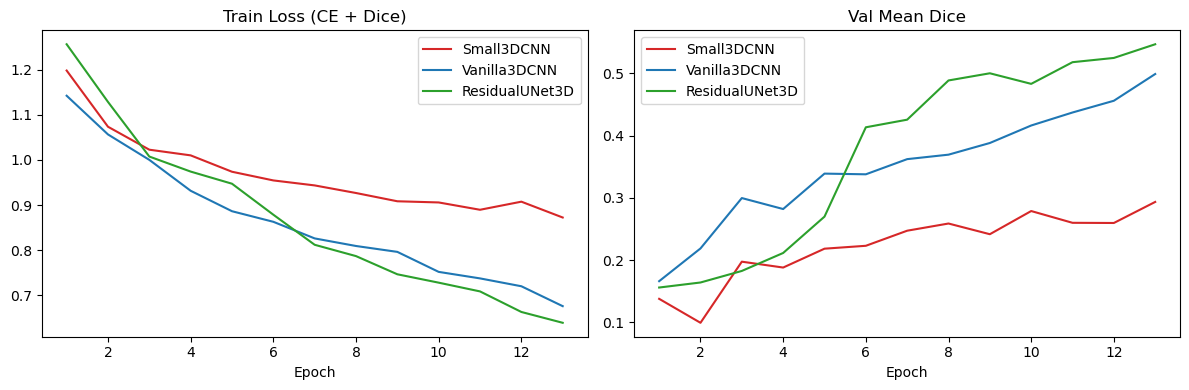

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for hist, label, color in [
    (hist_small, 'Small3DCNN',    'tab:red'),
    (hist_cnn,   'Vanilla3DCNN',  'tab:blue'),
    (hist_unet,   'ResidualUNet3D',  'tab:green'),
]:
    epochs = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs, hist['train_loss'], label=label, color=color)
    axes[1].plot(epochs, hist['val_dice'],   label=label, color=color)

axes[0].set_title('Train Loss (CE + Dice)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Val Mean Dice')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 10. End-to-End: Age Prediction from Predicted Segmentation of MRI


In [48]:
# Use the trained segmentation models to segment tissues on val set,
# then extracting volumes from those predicted masks and run ridge regression to predict age.

def extract_predicted_volumes(model, val_ds):
    model.eval()
    rows = []
    with torch.no_grad():
        for img, _ in val_ds:
            img_batch = img.unsqueeze(0).to(device)  # [1, 1, D, H, W]
            logits = model(img_batch)
            pred = logits.argmax(dim=1).squeeze().cpu().numpy()  # [D, H, W]

            # count voxels per label (using resized 64^3 space)
            voxel_vol = 0.5 * 0.5 * 0.5
            row = {f'label_{l}': np.sum(pred == l) * voxel_vol for l in range(1, 8)}
            rows.append(row)
    return pd.DataFrame(rows)


# get GT ages for val subjects
val_indices = val_ds.indices
all_ages = pd.read_csv(path_gt, sep='\t')['Gestational age'].values
y_val_ages = all_ages[val_indices].astype(float)

# saving subject ids for later analysis
val_subject_ids = [os.path.basename(image_paths[i]).split('_')[0] for i in val_indices]
age_preds = {} # per model

print("End-to-end age prediction on val set:")
print("-" * 40)

for model_name, model in [
    ('Small3DCNN',    model_small),
    ('Vanilla3DCNN',  model_cnn),
    ('ResidualUNet3D', model_unet),
]:
    pred_vols = extract_predicted_volumes(model, val_ds)

    Xv = pred_vols.values.astype(float)
    Xv_s = (Xv - ridge_mean) / ridge_std
    Xv_b = np.hstack([np.ones((len(Xv_s), 1)), Xv_s])

    y_pred = (Xv_b @ ridge_w).ravel()
    age_preds[model_name] = y_pred  # save for analysis

    rmse = np.sqrt(np.mean((y_val_ages - y_pred) ** 2))
    ss_r = np.sum((y_val_ages - y_pred) ** 2)
    ss_t = np.sum((y_val_ages - y_val_ages.mean()) ** 2)
    r2 = 1 - ss_r / ss_t

    print(f"{model_name}: RMSE={rmse:.3f} weeks, R2={r2:.3f}")

print(f"\nBaseline (GT vols, test set): RMSE={np.sqrt(test_mse):.3f} weeks")

End-to-end age prediction on val set:
----------------------------------------
Small3DCNN: RMSE=8.522 weeks, R2=-7.088
Vanilla3DCNN: RMSE=3.416 weeks, R2=-0.299
ResidualUNet3D: RMSE=8.966 weeks, R2=-7.954

Baseline (GT vols, test set): RMSE=1.073 weeks


# 11. Note on significant Worse results above:

Even though our segmentation models got decent Dice scores (0.50 for Vanilla3DCNN and 0.55 for ResidualUNet3D), the end-to-end age prediction is much worse than what we got with GT volumes. We think this is because we attempted to apply the ridge regression trained on ground-truth tissue volumes directly to predicted volumes from our segmentation models. This produced poor results (negative R^2) because each segmentation model has biases in its predicted voxel counts, a classic out-of-distribution scenario.

## Alternative:

- Train age prediction ridge regression from the models' segmentation outputs.
- The features at train and test time come from the same distribution (the model's own predictions)
- The bias the model has — over-predicting White matter, missing brainstem, etc. — the regression absorbs it as a learned weight. 

In [58]:
def extract_predicted_volumes(model, ds):
    model.eval()
    rows = []
    with torch.no_grad():
        for img, _ in ds:
            img_batch = img.unsqueeze(0).to(device)
            logits = model(img_batch)
            pred = logits.argmax(dim=1).squeeze().cpu().numpy()
            row = {f'label_{l}': float(np.sum(pred == l)) for l in range(1, 8)}
            rows.append(row)
    return pd.DataFrame(rows)


# Get ages aligned with train_ds / val_ds indices
train_indices = train_ds.indices
val_indices   = val_ds.indices
all_ages = pd.read_csv(path_gt, sep='\t')['Gestational age'].values
y_train_ages = all_ages[train_indices].astype(float).reshape(-1, 1)
y_val_ages   = all_ages[val_indices].astype(float)

val_subject_ids = [os.path.basename(image_paths[i]).split('_')[0] for i in val_indices]
age_preds = {}

print("End-to-end age prediction on val set (ridge trained on each model's predictions):")
print("-" * 70)
print(f"{'Model':<18} {'Best lam':>10} {'RMSE':>10} {'R2':>8}")
print("-" * 70)

for model_name, model in [
    ('Small3DCNN',     model_small),
    ('Vanilla3DCNN',   model_cnn),
    ('ResidualUNet3D', model_unet),
]:
    train_pred_vols = extract_predicted_volumes(model, train_ds)
    Xtr = train_pred_vols.values.astype(float)

    val_pred_vols = extract_predicted_volumes(model, val_ds)
    Xv = val_pred_vols.values.astype(float)

    m, s = Xtr.mean(0), Xtr.std(0)
    s[s == 0] = 1.0
    Xtr_s = (Xtr - m) / s
    Xv_s  = (Xv  - m) / s

    Xtr_b = np.hstack([np.ones((len(Xtr_s), 1)), Xtr_s])
    Xv_b  = np.hstack([np.ones((len(Xv_s),  1)), Xv_s])

    val_scores_m = cross_val_lambda(Xtr_b, y_train_ages, lambdas)
    best_lam_m = lambdas[np.argmin(val_scores_m)]
    w_m = ridge(Xtr_b, y_train_ages, best_lam_m)

    y_pred = (Xv_b @ w_m).ravel()
    age_preds[model_name] = y_pred

    rmse = np.sqrt(np.mean((y_val_ages - y_pred) ** 2))
    ss_r = np.sum((y_val_ages - y_pred) ** 2)
    ss_t = np.sum((y_val_ages - y_val_ages.mean()) ** 2)
    r2 = 1 - ss_r / ss_t

    print(f"{model_name:<18} {best_lam_m:>10.4f} {rmse:>10.3f} {r2:>8.3f}")

print(f"\nNative-res baseline (sec 2): RMSE={np.sqrt(test_mse):.3f} weeks")

End-to-end age prediction on val set (ridge trained on each model's predictions):
----------------------------------------------------------------------
Model                Best lam       RMSE       R2
----------------------------------------------------------------------
Small3DCNN            25.5955      1.561    0.728
Vanilla3DCNN           2.6827      1.232    0.831
ResidualUNet3D         4.7149      0.843    0.921

Native-res baseline (sec 2): RMSE=1.073 weeks


## Note on above results:

By training a separate ridge regression per model using each model's own predicted training volumes paired with the true ages, the regression absorbed each model's volumetric biases. With this approach, all three models achieve positive R^2 on validation, and ResidualUNet3D reaches RMSE = 0.84 weeks (R^2 = 0.92), comparable to the native-resolution GT-volume baseline.

## 12. Analysis: Where Does The Model Go Wrong?

A few things we want to look at:
- predicted vs true age scatter plot
- residuals (y_pred - y_true)
- which subjects have the worst predictions, which have the best?
- does the error depend on gestational age (younger fetuses harder to predict)?


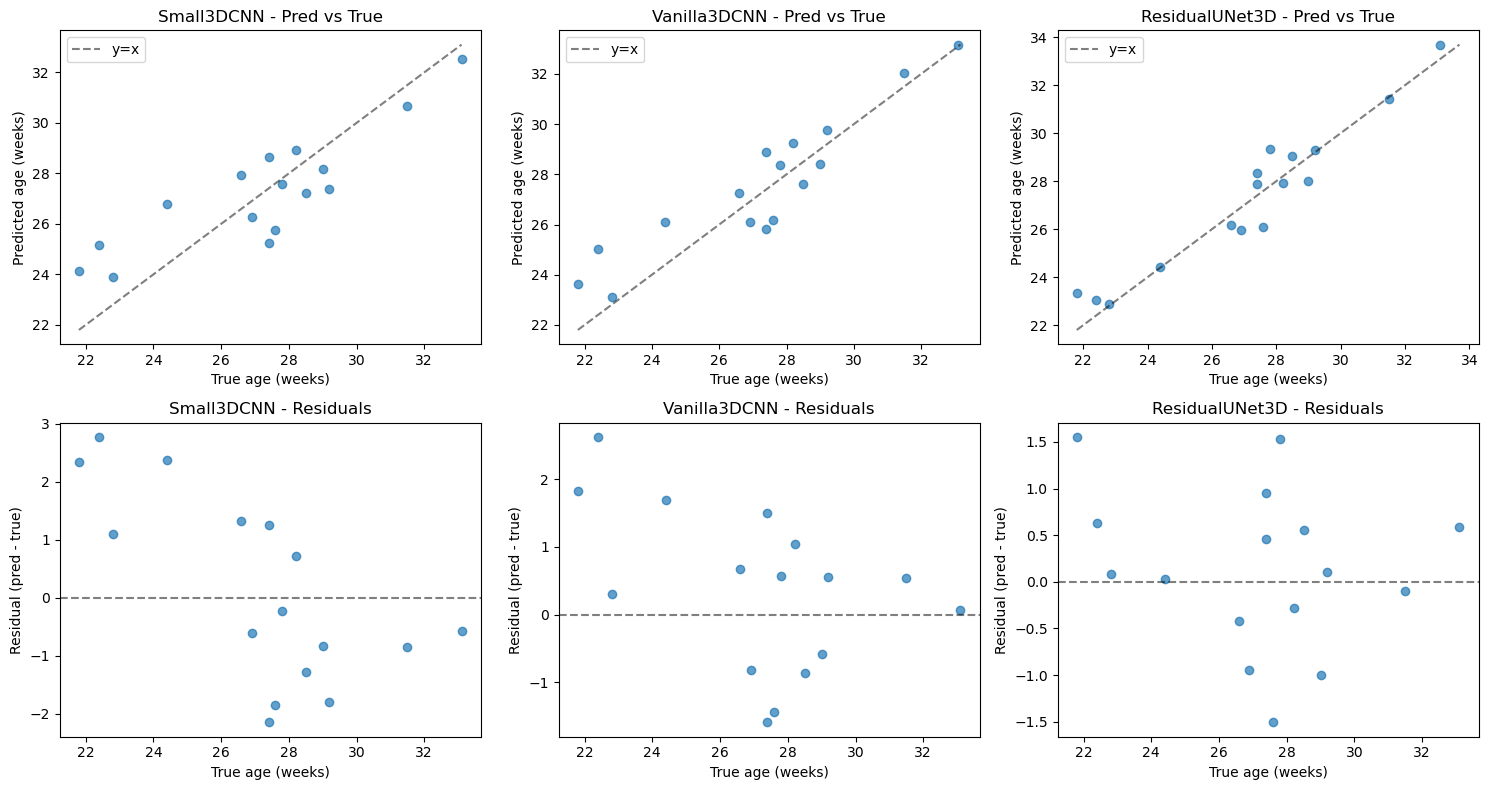

In [51]:
# Predicted vs true scatter + residuals for each model

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (model_name, y_pred) in enumerate(age_preds.items()):
    y_true = y_val_ages
    residuals = y_pred - y_true

    # Top row: predicted vs true scatter
    ax = axes[0, col]
    ax.scatter(y_true, y_pred, alpha=0.7)
    # diagonal y=x line for reference
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='y=x')
    ax.set_xlabel('True age (weeks)')
    ax.set_ylabel('Predicted age (weeks)')
    ax.set_title(f'{model_name} - Pred vs True')
    ax.legend()

    # Bottom row: residuals vs true age
    ax = axes[1, col]
    ax.scatter(y_true, residuals, alpha=0.7)
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('True age (weeks)')
    ax.set_ylabel('Residual (pred - true)')
    ax.set_title(f'{model_name} - Residuals')

plt.tight_layout()
plt.savefig('age_pred_analysis.png', dpi=150)
plt.show()

In [53]:
# Show worst and best predicted subjects per model

K = 5  # how many to show

for model_name, y_pred in age_preds.items():
    y_true = y_val_ages
    abs_err = np.abs(y_pred - y_true)

    df_results = pd.DataFrame({
        'subject':   val_subject_ids,
        'true_age':  y_true,
        'pred_age':  y_pred,
        'abs_error': abs_err,
    })

    print(f"\n=== {model_name} ===")
    print(f"Worst {K} predictions:")
    print(df_results.nlargest(K, 'abs_error').to_string(index=False))

    print(f"\nBest {K} predictions:")
    print(df_results.nsmallest(K, 'abs_error').to_string(index=False))


=== Small3DCNN ===
Worst 5 predictions:
subject  true_age  pred_age  abs_error
sub-071      22.4 25.170467   2.770467
sub-062      24.4 26.773208   2.373208
sub-066      21.8 24.145378   2.345378
sub-003      27.4 25.247419   2.152581
sub-011      27.6 25.746853   1.853147

Best 5 predictions:
subject  true_age  pred_age  abs_error
sub-026      27.8 27.576911   0.223089
sub-050      33.1 32.527168   0.572832
sub-077      26.9 26.289897   0.610103
sub-057      28.2 28.919912   0.719912
sub-075      29.0 28.163284   0.836716

=== Vanilla3DCNN ===
Worst 5 predictions:
subject  true_age  pred_age  abs_error
sub-071      22.4 25.024647   2.624647
sub-066      21.8 23.624513   1.824513
sub-062      24.4 26.090094   1.690094
sub-003      27.4 25.805817   1.594183
sub-069      27.4 28.905219   1.505219

Best 5 predictions:
subject  true_age  pred_age  abs_error
sub-050      33.1 33.168741   0.068741
sub-017      22.8 23.108550   0.308550
sub-068      31.5 32.046296   0.546296
sub-019      29.

In [56]:
# Bin subjects by age range to check if error is bigger for younger or older fetuses

age_bins = [20, 25, 28, 32, 36]  # rough trimester-ish bins for fetal scans
bin_labels = ['20-25', '25-28', '28-32', '32-36']

print(f"{'Model':<18} | " + " | ".join(f"{lbl:<8}" for lbl in bin_labels))
print("-" * 70)

for model_name, y_pred in age_preds.items():
    y_true = y_val_ages
    abs_err = np.abs(y_pred - y_true)

    bin_idx = np.digitize(y_true, age_bins) - 1
    bin_idx = np.clip(bin_idx, 0, len(bin_labels) - 1)

    row = f"{model_name:<18} | "
    for b in range(len(bin_labels)):
        mask = bin_idx == b
        if mask.sum() == 0:
            row += f"{'  -   ':<8} | "
        else:
            mean_err = abs_err[mask].mean()
            row += f"{mean_err:.3f}  ({mask.sum():>2}) | "
    print(row)

print("\n(values = mean abs error in weeks, (n) = subjects in that bin)")

Model              | 20-25    | 25-28    | 28-32    | 32-36   
----------------------------------------------------------------------
Small3DCNN         | 2.146  ( 4) | 1.238  ( 6) | 1.097  ( 5) | 0.573  ( 1) | 
Vanilla3DCNN       | 1.612  ( 4) | 1.099  ( 6) | 0.721  ( 5) | 0.069  ( 1) | 
ResidualUNet3D     | 0.575  ( 4) | 0.971  ( 6) | 0.407  ( 5) | 0.590  ( 1) | 

(values = mean abs error in weeks, (n) = subjects in that bin)


## Save Checkpoints


In [57]:
save_dir = os.path.join(path_base, 'checkpoints')
os.makedirs(save_dir, exist_ok=True)

for name, model in [
    ('small3dcnn',    model_small),
    ('vanilla3dcnn',  model_cnn),
    ('residualunet3d', model_unet),
]:
    ckpt_path = os.path.join(save_dir, f'{name}_best.pt')
    torch.save(model.state_dict(), ckpt_path)
    print(f'Saved {ckpt_path}')

Saved /home/ram/classes/EE 559/proj/feta_2.4/checkpoints/small3dcnn_best.pt
Saved /home/ram/classes/EE 559/proj/feta_2.4/checkpoints/vanilla3dcnn_best.pt
Saved /home/ram/classes/EE 559/proj/feta_2.4/checkpoints/residualunet3d_best.pt
